In [ ]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 0.2.1
Uninstalling kaleido-0.2.1:
  Successfully uninstalled kaleido-0.2.1
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)


In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly as px
import plotly.express as px
import kaleido
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

# Uploading and preparing data

In [ ]:
path = kagglehub.dataset_download("rohitgrewal/hr-data-mnc")
print("Path to dataset files:", 'HR_Data_MNC_Data Science Lovers.csv')

Using Colab cache for faster access to the 'hr-data-mnc' dataset.
Path to dataset files: HR_Data_MNC_Data Science Lovers.csv


In [ ]:
file_path = path + "/HR_Data_MNC_Data Science Lovers.csv"
data = pd.read_csv(file_path)
data

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [ ]:
data.head(10)

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
5,5,EMP0000006,Jason Gardner,Operations,Logistics Coordinator,2021-02-23,"Zimmermanstad, Bulgaria",5,4,Active,On-site,641393
6,6,EMP0000007,Julie Wright,Finance,Finance Manager,2016-04-04,"Karenfort, South Africa",2,9,Active,On-site,1383891
7,7,EMP0000008,Scott Wilson,Sales,Account Manager,2020-04-04,"Moniqueview, British Virgin Islands",2,5,Active,Remote,423091
8,8,EMP0000009,Cathy Thompson,Finance,Financial Analyst,2018-05-29,"South Catherine, Belize",4,7,Resigned,Remote,1138452
9,9,EMP0000010,Maria Yu MD,IT,Software Engineer,2015-10-08,"Brownport, Yemen",4,9,Active,Remote,1543102


In [ ]:
data.tail(10)

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
1999990,1999990,EMP1999991,Frank Ware,R&D,Product Developer,2015-11-16,"West Jaketon, Malta",2,9,Active,Remote,1178437
1999991,1999991,EMP1999992,Donald Brooks,Marketing,SEO Specialist,2014-08-03,"Port Cameron, Switzerland",2,11,Active,On-site,999129
1999992,1999992,EMP1999993,Phillip Small,IT,Data Analyst,2021-10-17,"Gonzalezstad, Korea",1,3,Active,On-site,957820
1999993,1999993,EMP1999994,Ashley Fuller,IT,DevOps Engineer,2018-06-09,"Dylanhaven, Bermuda",3,7,Terminated,Remote,892372
1999994,1999994,EMP1999995,Mrs. Denise Jones,Sales,Sales Director,2012-02-19,"Simpsonberg, Uganda",1,13,Active,Remote,450459
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727
1999999,1999999,EMP2000000,Angela Lambert,HR,Talent Acquisition Specialist,2020-11-11,"Morganchester, Canada",1,4,Active,Remote,993718


In [ ]:
data.info() # No duplicated values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


In [ ]:
data.columns

Index(['Unnamed: 0', 'Employee_ID', 'Full_Name', 'Department', 'Job_Title',
       'Hire_Date', 'Location', 'Performance_Rating', 'Experience_Years',
       'Status', 'Work_Mode', 'Salary_INR'],
      dtype='object')

# Data cleaning

In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
Employee_ID,0
Full_Name,0
Department,0
Job_Title,0
Hire_Date,0
Location,0
Performance_Rating,0
Experience_Years,0
Status,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data[data.isnull().any(axis=1)]

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR


In [ ]:
data.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
data['Salary_USD'] = data['Salary_INR'] * 0.011

In [ ]:
data

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_USD
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,17438.993
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,9324.546
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,15730.924
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,10897.579
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,5885.902
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648,7234.128
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109,11331.199
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085,14443.935
1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727,16276.997


# EDA

In [ ]:
for i in data.select_dtypes(include='O'):
    if i!= "Employee_ID":
        print(data[i].value_counts())
        print()

Full_Name
Michael Smith            1014
Michael Johnson           781
David Smith               634
Jennifer Smith            624
Michael Williams          609
                         ... 
Courtney Mcknight           1
Mrs. Jessica Watson         1
April Mcclain DVM           1
Allison Fernandez DVM       1
Ms. Peggy Rodriguez         1
Name: count, Length: 467487, dtype: int64

Department
IT            601042
Sales         400031
Operations    300095
Marketing     240081
Finance       199873
HR            159119
R&D            99759
Name: count, dtype: int64

Job_Title
Software Engineer                300358
Sales Executive                  199982
Operations Executive             150058
Data Analyst                     120375
Marketing Executive              120154
Account Manager                  119929
Accountant                       100307
DevOps Engineer                   90197
Logistics Coordinator             90188
HR Executive                      79348
SEO Specialist        

In [ ]:
data.describe()

,Performance_Rating,Experience_Years,Salary_INR,Salary_USD
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.000148e+00,5.010287e+00,8.968878e+05,9.865765e+03
std,1.413973e+00,3.608823e+00,4.026103e+05,4.428713e+03
min,1.000000e+00,0.000000e+00,3.000000e+05,3.300000e+03
25%,2.000000e+00,2.000000e+00,6.163460e+05,6.779806e+03
50%,3.000000e+00,5.000000e+00,8.110265e+05,8.921291e+03
75%,4.000000e+00,8.000000e+00,1.073745e+06,1.181120e+04
max,5.000000e+00,1.500000e+01,2.999976e+06,3.299974e+04


In [ ]:
data.describe(include='O')

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Status,Work_Mode
count,2000000,2000000,2000000,2000000,2000000,2000000,2000000,2000000
unique,2000000,467487,7,29,5479,1593497,4,2
top,EMP1999984,Michael Smith,IT,Software Engineer,2022-10-31,"Lake Michael, Congo",Active,On-site
freq,1,1014,601042,300358,622,20,1401558,1199109


`Salary Distribution`

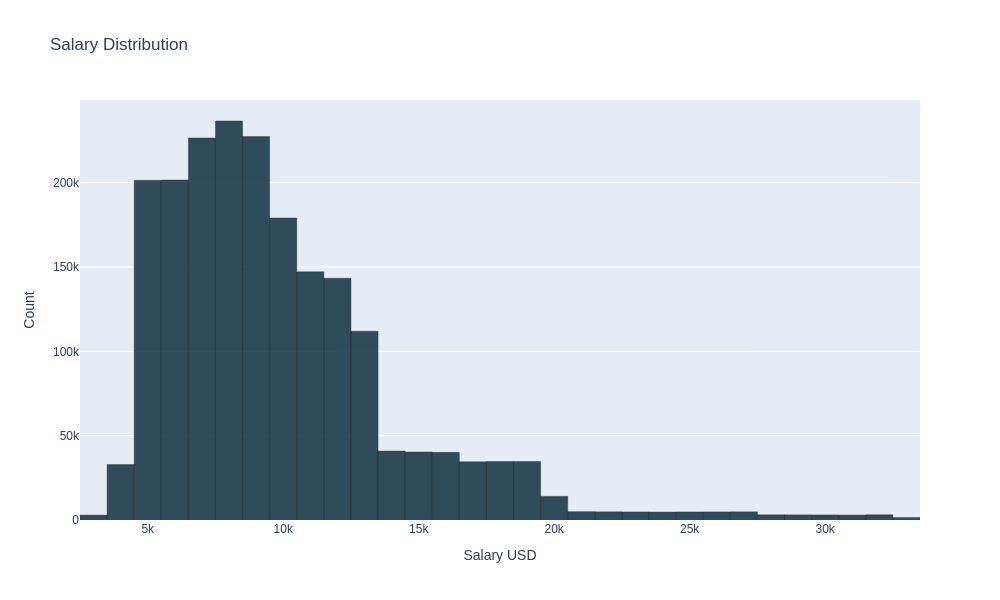

In [ ]:
fig = px.histogram(data,x='Salary_USD',nbins=50,opacity=0.8,color_discrete_sequence=px.colors.sequential.thermal,
                   title='Salary Distribution')
fig.update_traces(marker=dict(line=dict(color='black', width=0.4)))
fig.update_layout(width=1000,height=600,xaxis_title='Salary USD',yaxis_title='Count',title='Salary Distribution')
fig.write_image("fig1_chart.png", engine="kaleido")
display(Image(filename="fig1_chart.png"))

Due to the presence of outliers, the graph shows an extreme rightward skewness.

`Outliers`

In [ ]:
def outlier(df,column):
    q1 = df[column].quantile(.25)
    q3 = df[column].quantile(.75)
    IQR = q3-q1
    upper = q3 + (1.5*IQR)
    lower = q1 - (1.5*IQR)
    print(upper,lower)
    dataoutliers = df[(df[column] > upper) | (df[column] < lower)]
    return dataoutliers

In [ ]:
dataout = outlier(data,'Salary_USD')
dataout

19358.285375 -767.2816250000005


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_USD
24,EMP0000025,Amanda Miller,IT,IT Manager,2021-07-31,"Tammyview, Barbados",2,4,Active,Remote,2153098,23684.078
32,EMP0000033,Cristian Thomas,IT,IT Manager,2021-02-14,"North Markbury, San Marino",3,4,Active,Remote,2408177,26489.947
34,EMP0000035,Kathleen Shields,IT,IT Manager,2023-07-26,"North Brianmouth, Zambia",1,2,Retired,On-site,2615626,28771.886
103,EMP0000104,Tamara Wilson,Finance,Finance Manager,2023-01-10,"South Stevenmouth, South Georgia and the South...",2,2,Resigned,On-site,2118072,23298.792
143,EMP0000144,Jane Mcintyre,IT,IT Manager,2024-09-16,"Housemouth, Guam",4,0,Active,On-site,2194883,24143.713
...,...,...,...,...,...,...,...,...,...,...,...,...
1999878,EMP1999879,Kyle Harrington,IT,Software Engineer,2017-03-26,"Joshuaton, Pakistan",5,8,Resigned,On-site,1787416,19661.576
1999891,EMP1999892,Amy Larson,IT,IT Manager,2025-01-30,"Scottbury, Panama",5,0,Active,Remote,2280784,25088.624
1999908,EMP1999909,Adam Parker,IT,IT Manager,2023-01-10,"Keithland, Andorra",1,2,Active,Remote,2797393,30771.323
1999941,EMP1999942,Lisa Sanders,Finance,Finance Manager,2016-03-14,"Emmaberg, Argentina",2,9,Active,On-site,2010855,22119.405


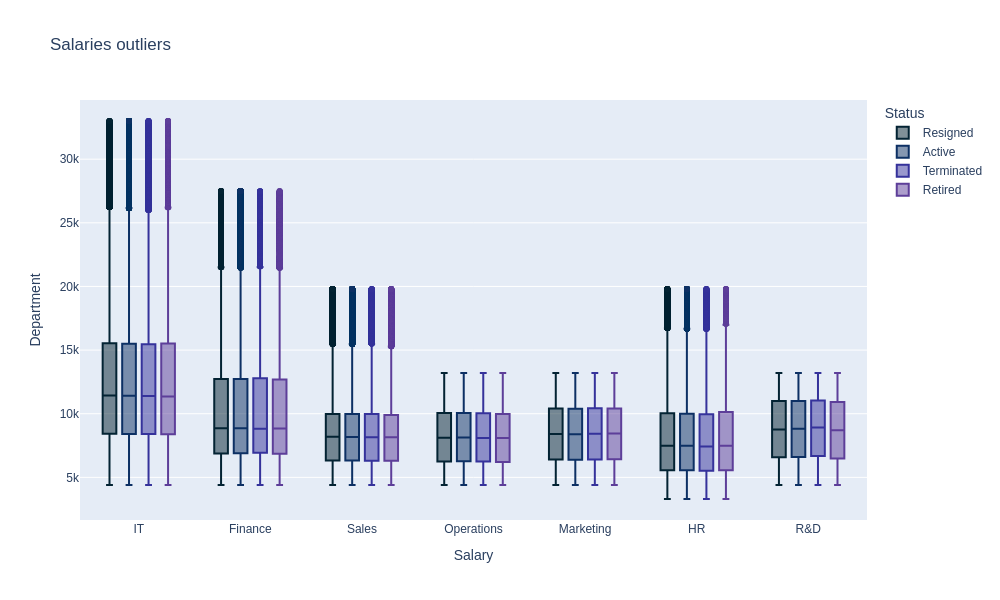

In [ ]:
fig = px.box(data,x='Department', y="Salary_USD",color='Status',color_discrete_sequence=px.colors.sequential.thermal,
             title='Salaries outliers')
fig.update_layout( width=1000,height=600,xaxis_title='Salary',yaxis_title='Department')
fig.write_image("fig2_chart.png", engine="kaleido")
display(Image(filename="fig2_chart.png"))

Many outliers were found

In [ ]:
dataout.describe(include='O')

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Status,Work_Mode
count,69298,69298,69298,69298,69298,69298,69298,69298
unique,69298,52977,4,5,5437,68550,4,2
top,EMP1999945,Michael Smith,IT,IT Manager,2024-01-30,"Port Shawn, Macao",Active,On-site
freq,1,39,51685,41507,36,3,48513,41525


In [ ]:
dataout.describe()

,Performance_Rating,Experience_Years,Salary_INR,Salary_USD
count,69298.000000,69298.000000,6.929800e+04,69298.000000
mean,2.993146,5.022338,2.210338e+06,24313.722014
std,1.416792,3.611990,3.743006e+05,4117.306127
min,1.000000,0.000000,1.759846e+06,19358.306000
25%,2.000000,2.000000,1.833834e+06,20172.174000
50%,3.000000,5.000000,2.159640e+06,23756.045500
75%,4.000000,8.000000,2.487297e+06,27360.264250
max,5.000000,15.000000,2.999976e+06,32999.736000


`Department in outliers`

The share of department in salaries that are outliers:
IT         74.583682
Finance    20.931340
Other       4.484978
dtype: float64



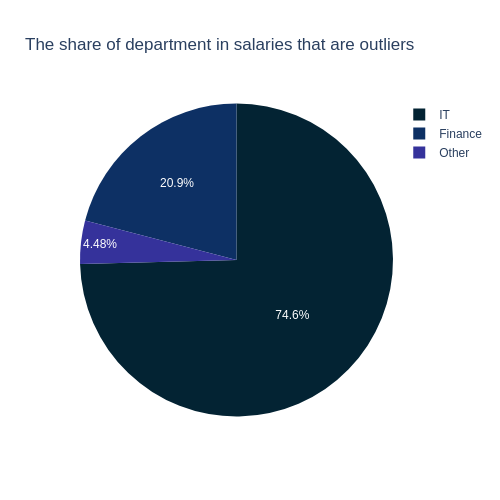

In [ ]:
depout = dataout['Department'].value_counts(normalize=True)*100
top2=depout.head(2)
other=depout.iloc[2:].sum()
depout_final=pd.concat([top2,pd.Series({'Other':other})])
print(f'The share of department in salaries that are outliers:\n{depout_final}')
print()

# Visualization

fig = px.pie(depout_final,values=depout_final.values,names=depout_final.index,title="The share of department in salaries that are outliers",
             color_discrete_sequence=px.colors.sequential.thermal)
fig.update_layout(width=500,height=500)
fig.write_image("fig3_chart.png", engine="kaleido")
display(Image(filename="fig3_chart.png"))

`Job title in outliers`

The share of job title in salaries that are outliers:
Job_Title
IT Manager                      59.896390
Finance Manager                 20.931340
Software Engineer               14.687293
Business Development Manager     3.207885
HR Manager                       1.277093
Name: proportion, dtype: float64



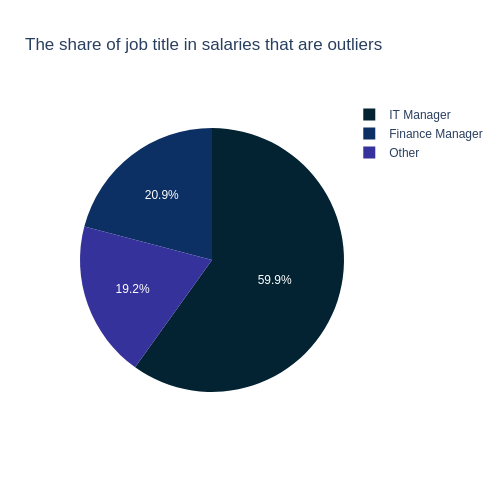

In [ ]:
jobout = dataout['Job_Title'].value_counts(normalize=True) * 100
top2=jobout.head(2)
other=jobout.iloc[2:].sum()
jobout_final= pd.concat([top2, pd.Series({'Other': other})])
print(f'The share of job title in salaries that are outliers:\n{jobout}')
print()

# Visualization

fig = px.pie(jobout_final,values=jobout_final.values,names=jobout_final.index,title="The share of job title in salaries that are outliers",
             color_discrete_sequence=px.colors.sequential.thermal)
fig.update_layout(width=500,height=500)
fig.write_image("fig4_chart.png", engine="kaleido")
display(Image(filename="fig4_chart.png"))

`Distribution of employees status`

Distibution of employees status:
Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: count, dtype: int64



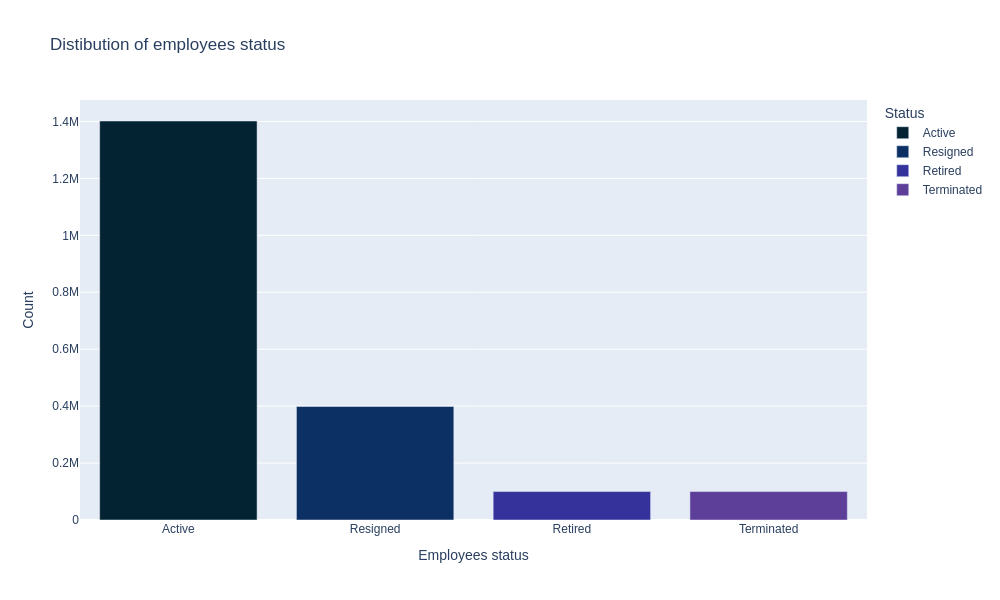

In [ ]:
status=data['Status'].value_counts()
print(f'Distibution of employees status:\n{status}')
print()

# Visualization

fig = px.bar(status,x=status.index,y=status.values,color=status.index,color_discrete_sequence=px.colors.sequential.thermal,
    title='Distibution of employees status',
    hover_name=status.index)

fig.update_layout( width=1000,
    height=600,
    xaxis_title='Employees status',
    yaxis_title='Count')

fig.write_image("fig5_chart.png", engine="kaleido")
display(Image(filename="fig5_chart.png"))

`Work mode distribution`

Work mode distribution:
Work_Mode
On-site    59.95545
Remote     40.04455
Name: proportion, dtype: float64



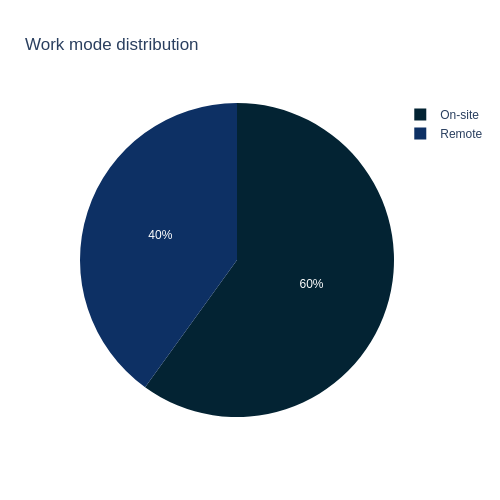

In [ ]:
workmode = data['Work_Mode'].value_counts(normalize=True)*100
print(f'Work mode distribution:\n{workmode}')
print()

# Visualization

fig = px.pie(workmode,values=workmode.values,names=workmode.index,title="Work mode distribution",
             color_discrete_sequence=px.colors.sequential.thermal)
fig.update_layout(width=500,height=500)
fig.write_image("fig6_chart.png", engine="kaleido")
display(Image(filename="fig6_chart.png"))

`Number of the employees in each department`

In [ ]:
data.groupby('Department')['Job_Title'].value_counts().reset_index()

,Department,Job_Title,count
0,Finance,Accountant,100307
1,Finance,Financial Analyst,59815
2,Finance,Finance Manager,29799
3,Finance,CFO,9952
4,HR,HR Executive,79348
5,HR,Talent Acquisition Specialist,47994
6,HR,HR Manager,23841
7,HR,HR Director,7936
8,IT,Software Engineer,300358
9,IT,Data Analyst,120375


`Median salary in each department based on Job title`

In [ ]:
data.groupby(['Department','Job_Title'])['Salary_USD'].median().reset_index()

,Department,Job_Title,Salary_USD
0,Finance,Accountant,7153.5640
1,Finance,CFO,8701.7700
2,Finance,Finance Manager,19155.6860
3,Finance,Financial Analyst,11559.0970
4,HR,HR Director,8853.0530
5,HR,HR Executive,6064.7840
6,HR,HR Manager,13790.8980
7,HR,Talent Acquisition Specialist,8820.2840
8,IT,CTO,8825.3880
9,IT,Data Analyst,8817.0060


`Median salary per department`

Median salary per department:
Department
IT            11403.425
Finance        8859.741
R&D            8810.604
Marketing      8399.490
Sales          8177.400
Operations     8117.725
HR             7485.632
Name: Salary_USD, dtype: float64



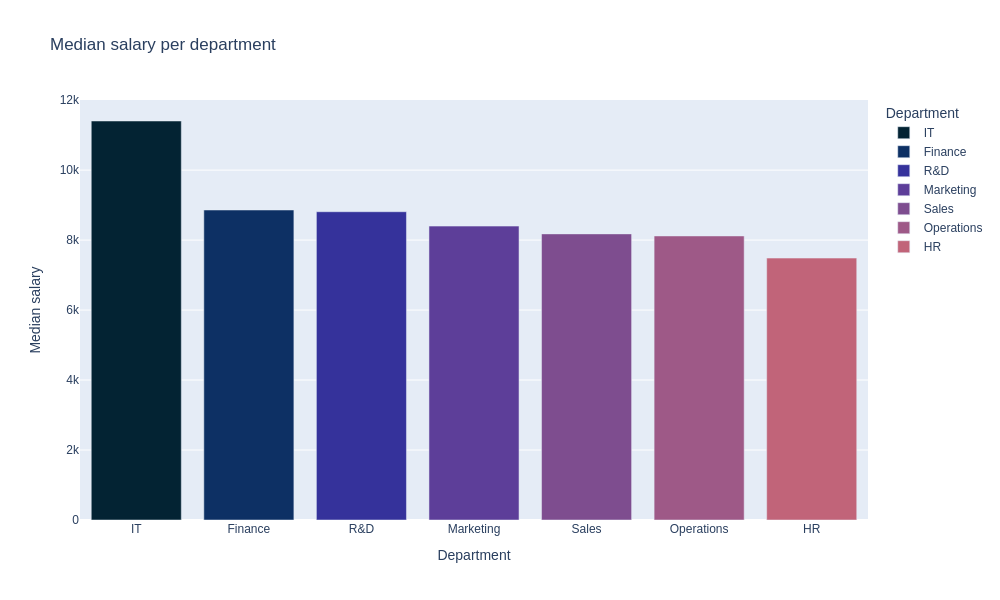

In [ ]:
salary_per_department = data.groupby('Department')['Salary_USD'].median().sort_values(ascending=False)
print(f'Median salary per department:\n{salary_per_department}')
print()
# Visualization
fig = px.bar(salary_per_department,x=salary_per_department.index,y=salary_per_department.values,color=salary_per_department.index,color_discrete_sequence=px.colors.sequential.thermal,
    title='Median salary per department',
    hover_name=salary_per_department.index)

fig.update_layout( width=1000,
    height=600,
    xaxis_title='Department',
    yaxis_title='Median salary')

fig.write_image("fig7_chart.png", engine="kaleido")
display(Image(filename="fig7_chart.png"))

`Median salary by job title`

Median salary by job title:
Job_Title
IT Manager                      23045.3685
Finance Manager                 19155.6860
HR Manager                      13790.8980
Business Development Manager    13787.4110
Software Engineer               13178.8415
Financial Analyst               11559.0970
Brand Manager                    8865.5160
HR Director                      8853.0530
Innovation Manager               8851.1170
Lab Technician                   8828.9960
Name: Salary_USD, dtype: float64



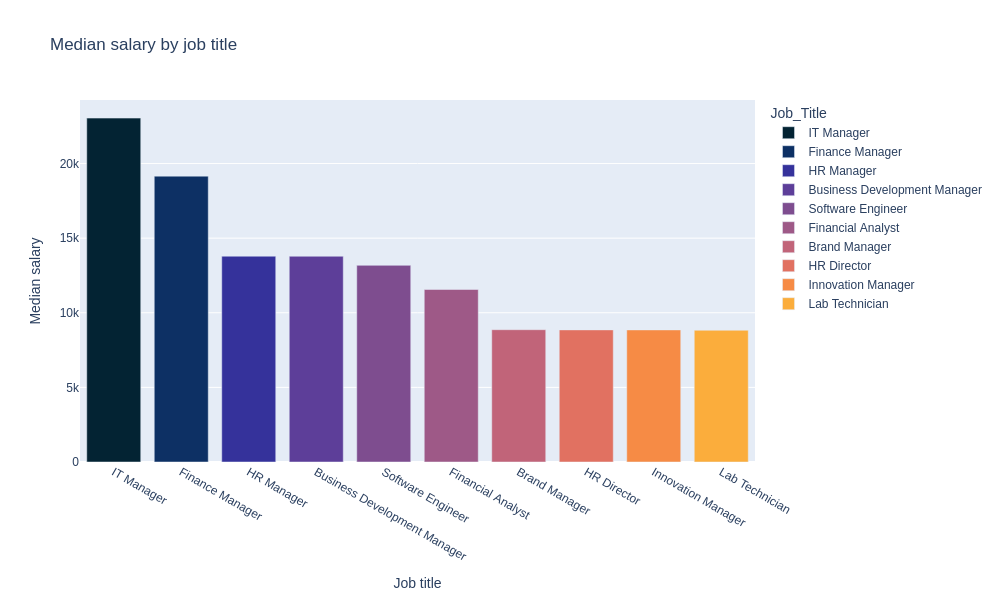

In [ ]:
salary_per_job_title = data.groupby('Job_Title')['Salary_USD'].median().sort_values(ascending=False).head(10)
print(f'Median salary by job title:\n{salary_per_job_title}')
print()

# Visualization

fig = px.bar(salary_per_job_title,x=salary_per_job_title.index,y=salary_per_job_title.values,
             color=salary_per_job_title.index,color_discrete_sequence=px.colors.sequential.thermal,
    title='Median salary by job title',
    hover_name=salary_per_job_title.index)

fig.update_layout( width=1000,
    height=600,
    xaxis_title='Job title',
    yaxis_title='Median salary')

fig.write_image("fig8_chart.png", engine="kaleido")
display(Image(filename="fig8_chart.png"))

`Salary across experience years`

Salary across experience years:
Experience_Years
0     8919.9220
1     8908.1245
2     8906.4525
3     8930.0420
4     8922.8150
5     8914.0700
6     8926.3680
7     8916.7320
8     8925.4000
9     8944.1880
10    8916.8970
11    8941.8340
12    8909.2630
13    8930.0970
14    8923.8270
15    9012.9050
Name: Salary_USD, dtype: float64



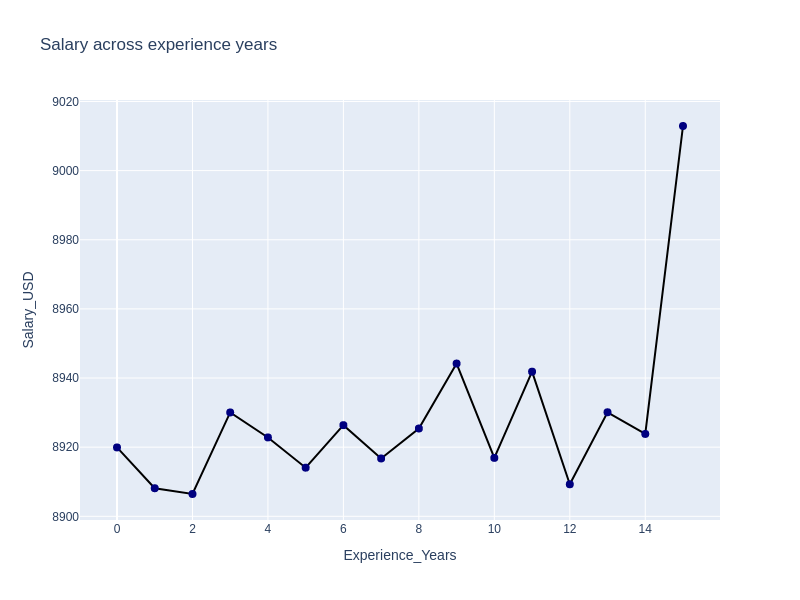

In [ ]:
salary_ex = data.groupby('Experience_Years')['Salary_USD'].median()
print(f'Salary across experience years:\n{salary_ex}')
print()

# Visualization

fig = px.line(salary_ex,x=salary_ex.index,y=salary_ex.values,markers=True,
              labels={'x': 'Experience_Years', 'y': 'Salary_USD'},title='Salary across experience years')

fig.update_layout(width=800,height=600)

fig.update_traces(marker=dict(color='navy',size=8),line=dict(color='black',width=2))
fig.write_image("fig9_chart.png", engine="kaleido")
display(Image(filename="fig9_chart.png"))

The graph indicates no pattern between the average salary and the years of experience.

`Average performance rating by department`

In [ ]:
performance_department = data.groupby('Department')['Performance_Rating'].mean().sort_values(ascending=False)
print(f'Performance rating by department:\n{performance_department}')

Performance rating by department:
Department
Sales         3.006362
Marketing     3.004736
R&D           3.001885
IT            2.998216
Finance       2.996818
Operations    2.996081
HR            2.995670
Name: Performance_Rating, dtype: float64


`Country that have the highest concentration of employees`

In [ ]:
data['Location'].value_counts().head(1)

,count
Location,
"Lake Michael, Congo",20


`Correlation`

<Axes: >

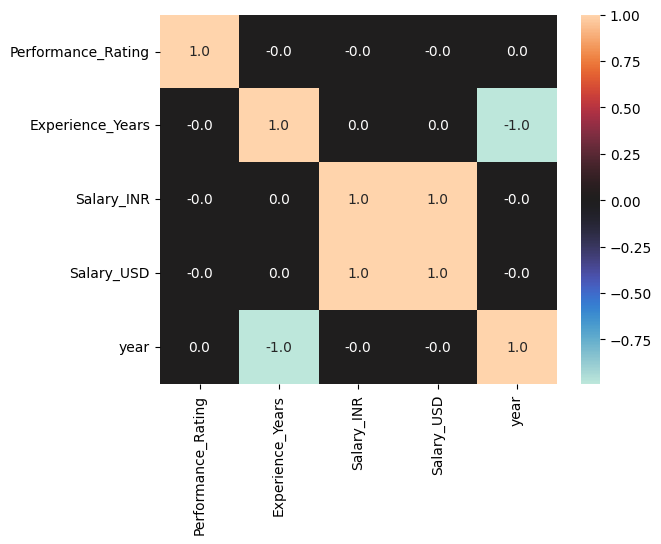

In [42]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt='.1f',cmap='icefire')

There was no correlation between the salary and performance rating, nor between the salary and the years of experience.

`Hiring over the years`

In [ ]:
data['Hire_Date']=pd.to_datetime(data['Hire_Date'])

Hiring over the time:
year
2010     15520
2011     40089
2012     39765
2013     39988
2014     40202
2015     85984
2016    160249
2017    160363
2018    159658
2019    160202
2020    175460
2021    199366
2022    201373
2023    198982
2024    200001
2025    122798
Name: count, dtype: int64


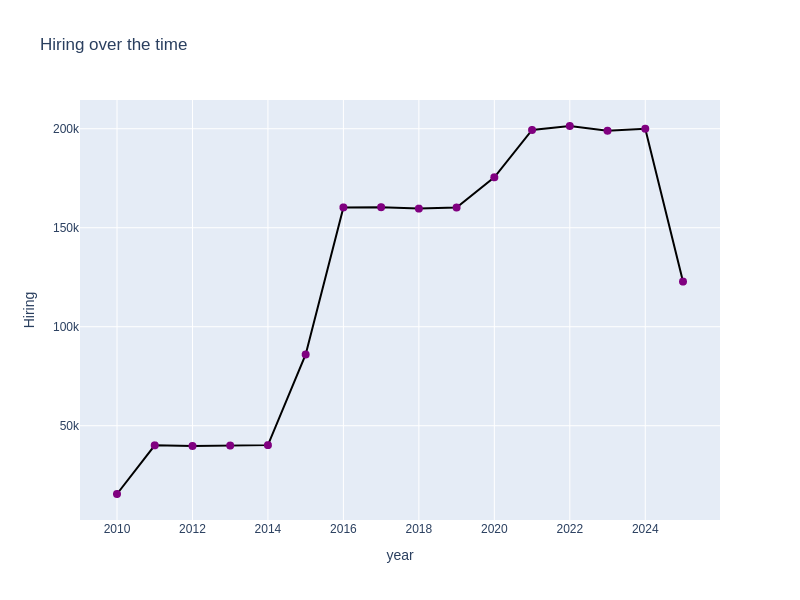

In [ ]:
data['year']=data['Hire_Date'].dt.year
VY = data['year'].value_counts().sort_index()
print(f'Hiring over the time:\n{VY}')

# Visualization

fig = px.line(VY,x=VY.index,y=VY.values,markers=True,
              labels={'x': 'Experience_Years', 'y': 'Hiring'},title='Hiring over the time')

fig.update_layout(width=800,height=600)

fig.update_traces(marker=dict(color='purple',size=8),line=dict(color='black',width=2))
fig.write_image("fig10_chart.png", engine="kaleido")
display(Image(filename="fig10_chart.png"))

`Salary over the years`

Salary over the years:
year
2010    8918.8605
2011    8933.2870
2012    8908.0750
2013    8917.6615
2014    8924.2285
2015    8965.6435
2016    8925.5760
2017    8929.4920
2018    8913.3605
2019    8918.4480
2020    8925.3670
2021    8922.5675
2022    8916.9630
2023    8906.9420
2024    8908.7350
2025    8929.5360
Name: Salary_USD, dtype: float64



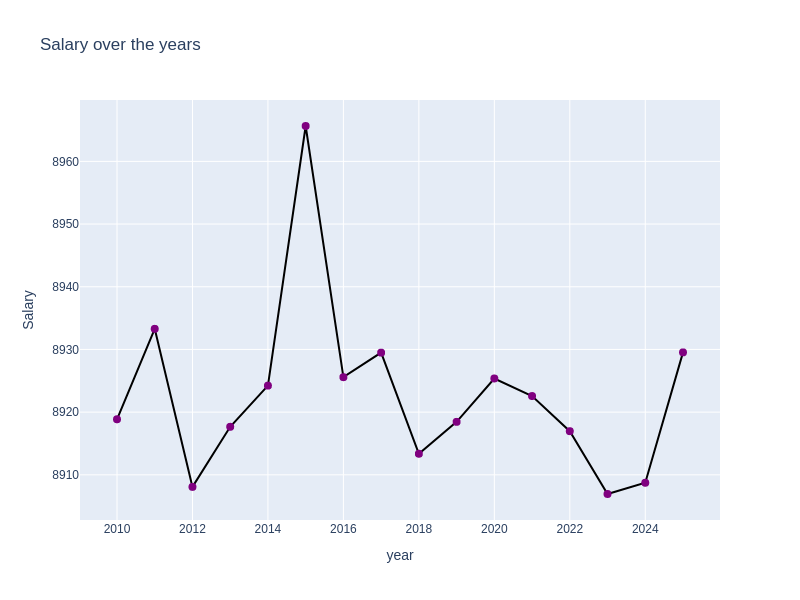

In [ ]:
saly = data.groupby('year')['Salary_USD'].median()
print(f'Salary over the years:\n{saly}')
print()

# Visualization

fig = px.line(saly,x=saly.index,y=saly.values,markers=True,
              labels={'x': 'years', 'y': 'Salary'},title='Salary over the years')

fig.update_layout(width=800,height=600)

fig.update_traces(marker=dict(color='purple',size=8),line=dict(color='black',width=2))
fig.write_image("fig11_chart.png", engine="kaleido")
display(Image(filename="fig11_chart.png"))

The graph indicates no pattern between the average salary over the years

`On site vs Remote`

In [ ]:
data.groupby('Work_Mode')['Salary_USD'].agg(['mean','median'])

,mean,median
Work_Mode,,
On-site,9865.195404,8922.694
Remote,9866.618590,8918.954


`Attrition rate per department`

In [ ]:
total_per_dept=data.groupby('Department')['Status'].count()
resigned_per_dept=data[data['Status'] == 'Resigned'].groupby('Department')['Status'].count()
attrition_rate=(resigned_per_dept/total_per_dept)* 100
attrition_rate=attrition_rate.sort_values(ascending=False)
attrition_rate

,Status
Department,
Finance,20.131784
R&D,19.967121
HR,19.944821
IT,19.940703
Sales,19.929705
Marketing,19.907031
Operations,19.792732


# Analysis and Insights

*   The IT department accounts for the majority of salary outliers, contributing 74.1% of the total. Likewise, the IT Manager role represents the highest share among job titles, making up 60.2% of all salary outliers.

*   Hiring has shown a steady upward trend over the years. However, salary progression and years of experience do not display any consistent pattern over time.

*   No significant correlation was identified between performance ratings and salary. Similarly, years of experience do not appear to have a meaningful impact on compensation.

*   There is no notable difference in salary levels between on-site and remote employees.


*   Attrition rates are relatively consistent across departments, with the Finance department showing a slightly higher resignation rate compared to others.


